In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from wordcloud import WordCloud
from collections import defaultdict
import spacy
import itertools
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
from tqdm.auto import tqdm
tqdm.pandas()

In [3]:
from constants import (
    JIBARO_WORDS, GIBARO_WORDS, CAMPESINO_WORDS, 
    LCCN_TO_NAME, BASE_PATH
)

In [4]:
nlp = spacy.blank("es")

In [5]:
def get_term_freqs(docs):
    tf = defaultdict(int)
    for t in itertools.chain.from_iterable(docs):
        t = t.lower_
        # Remove spanish stop words and punctuation
        if t in nlp.Defaults.stop_words or t in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' or len(t) < 2:
            continue
        tf[t] += 1
    return {'tf': dict(tf)}


In [6]:
data_df = pd.read_pickle('relevant_docs_df.pkl')
data_df['decade'] = (data_df['year'].astype(int) // 10) * 10

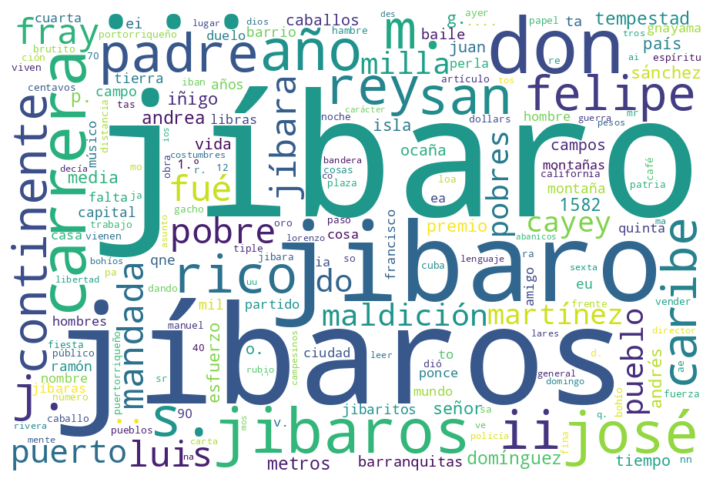

In [9]:
selected_df = data_df.loc[
    (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
    | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
]

tfs = get_term_freqs(selected_df['surrounding_text_jibar'])
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [20]:
nlp = spacy.load("es_core_news_sm")

In [40]:
jibara_docs_processed = selected_df['text_cleaned'].progress_apply(lambda s: nlp(s.replace('\n', ' ')))

  0%|          | 0/1616 [00:00<?, ?it/s]

In [59]:
def get_freq(words):
    frqs = defaultdict(int)
    for w in words:
        frqs[w] += 1
    return frqs

In [41]:
sentences = []
for doc in jibara_docs_processed:
    for t in doc:
        if t.lower_ in JIBARO_WORDS:
            sentences.append(t.sent)

In [66]:

pos_toks = defaultdict(list)
for s in sentences:
    for t in s:
        if len(t) > 2:
            pos_toks[t.pos_].append(t.lower_)

In [110]:
pos_toks.keys()

dict_keys(['VERB', 'ADJ', 'NOUN', 'ADV', 'SCONJ', 'DET', 'PRON', 'AUX', 'ADP', 'CCONJ', 'PUNCT', 'PROPN', 'NUM', 'INTJ', 'SYM', 'X', 'PART'])

# Simple POS Based Word CLoud

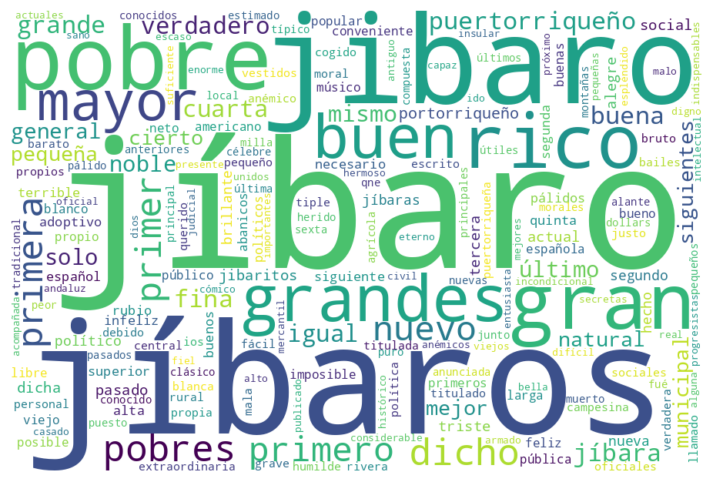

In [111]:
tfs = get_freq(pos_toks['ADJ'])
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs)
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

# Noun Phrase Based

In [155]:

def _span_for_subtree(doc, token):
    """Span covering token's dependency subtree."""
    left = min(t.i for t in token.subtree)
    right = max(t.i for t in token.subtree) + 1
    return doc[left:right]

def _get_nominal_head(token):
    """
    If `token` is a NOUN/PROPN (or used substantively), return it.
    If it's ADJ used as modifier, try to return its head noun.
    """
    if token.pos_ in {"NOUN", "PROPN"}:
        return token
    # 'jíbaro' might be tagged ADJ in some contexts; try head
    if token.head.pos_ in {"NOUN", "PROPN"}:
        return token.head
    return token  # fallback

def extract_jibaro_info(doc, targets=JIBARO_WORDS):
    hits = [t for t in doc if t.lower_ in targets]
    results = []

    for t in hits:
        noun = _get_nominal_head(t)

        # 1) Noun phrase span: noun_chunks if present, else subtree
        np_span = None
        if hasattr(doc, "noun_chunks"):
            for chunk in doc.noun_chunks:
                if noun.i >= chunk.start and noun.i < chunk.end:
                    np_span = chunk
                    break
        if np_span is None:
            np_span = _span_for_subtree(doc, noun)

        # 2) Adjectives directly modifying noun: amod + coordinated adjectives
        adjs = [c for c in noun.children if c.dep_ == "amod" and c.pos_ == "ADJ"]

        # include coordinated adjectives (e.g., "alto y fuerte")
        all_adjs = []
        for a in adjs:
            all_adjs.append(a)
            all_adjs.extend([cc for cc in a.conjuncts if cc.pos_ == "ADJ"])

        # 3) Adjective groups as spans (adjective subtree)
        adj_groups = []
        seen = set()
        for a in all_adjs:
            if a.i in seen:
                continue
            grp = _span_for_subtree(doc, a)
            adj_groups.append(grp)
            for tt in grp:
                seen.add(tt.i)

        results.append({
            "match_token": t,
            "nominal_head": noun,
            "noun_phrase": np_span,
            "adjectives": all_adjs,
            "adjective_groups": adj_groups,
        })

    return results

In [170]:
i += 1
info = extract_jibaro_info(sentences[i])
for r in info:
    print("NP:", r["noun_phrase"].text)
    print("Adjectives:", [a.text for a in r["adjectives"]])
    print("Adj groups:", [g.text for g in r["adjective_groups"]])
    print(sentences[i])

NP: trovadores jibaros
Adjectives: ['trovadores']
Adj groups: ['']
iqué furioso se pondrá áyuso cuando sepa que en sus dominios nubo tal jietta! el certamen de trovadores jibaros que se efectuó en el vecino pueblo de yauco du rante las tiestas patronales resulto muy concurrido xanimado.


In [201]:
noun_phrases = []
for s in sentences:
    info = extract_jibaro_info(s)
    for r in info:
        if r["noun_phrase"]:
            noun_phrases.append(r["noun_phrase"])


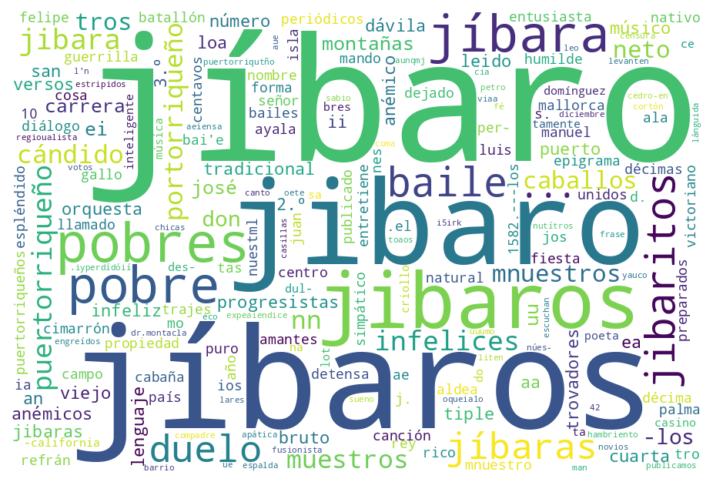

In [203]:

tfs = get_term_freqs(noun_phrases)
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

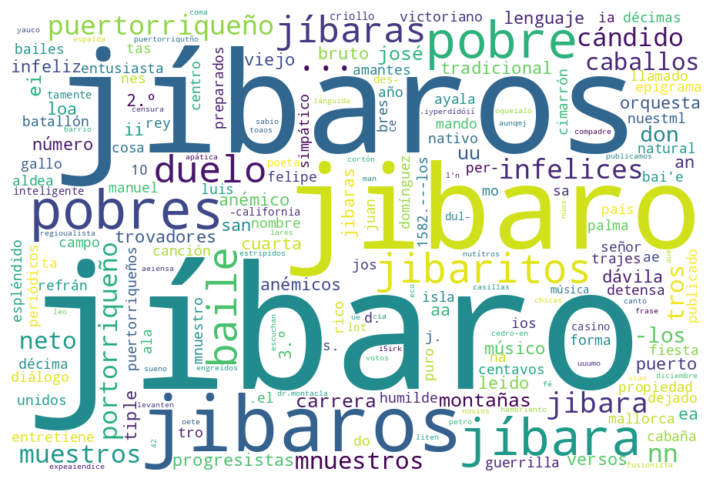

In [180]:

tfs = get_term_freqs(noun_phrases)
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [184]:
for t in sorted(tfs['tf'].items(), key=lambda item: -item[1]):
    if len(t[0]) > 2:
        print(t[0])

jíbaro
jíbaros
jibaro
jibaros
pobres
jíbara
pobre
jibaritos
baile
duelo
jíbaras
...
jibara
puertorriqueño
infelices
cándido
portorriqueño
muestros
tros
caballos
mnuestros
neto
don
-los
josé
montañas
carrera
jibaras
trovadores
viejo
anémico
anémicos
dávila
lenguaje
cuarta
bruto
progresistas
2.º
3.º
número
tiple
músico
san
loa
tradicional
versos
infeliz
orquesta
puerto
leido
ios
ayala
periódicos
cabaña
victoriano
cimarrón
nombre
tas
señor
canción
gallo
propiedad
manuel
centavos
puertorriqueños
décima
guerrilla
mando
batallón
entusiasta
dejado
per-
llamado
cosa
preparados
mallorca
campo
palma
juan
centro
isla
refrán
diálogo
humilde
fiesta
bailes
natural
nes
nativo
unidos
tro
.el
entretiene
ala
aldea
décimas
mnuestro
epigrama
luis
jos
nuestml
puro
publicado
trajes
simpático
rico
forma
detensa
país
espléndido
bai'e
amantes
1582.---los
rey
felipe
año
domínguez
bres
inteligente
dul-
-california
lot
poeta
música
des-
tamente
criollo
casino
nutítros
i5irk
fusionista
chicas
lares
eco
yauco
dicie

In [102]:
for token in nlp(examples[0]):
    print(f"Token: {token.text}")
    print(f"  POS tag: {token.pos_}")
    print(f"  Morphology: {token.morph}\n")
    print(f"  token.head: {token.head}\n")

Token: lo
  POS tag: PRON
  Morphology: Case=Acc|Gender=Masc|Number=Sing|Person=3|PrepCase=Npr|PronType=Prs

  token.head: consegaido

Token: han
  POS tag: AUX
  Morphology: Mood=Ind|Number=Plur|Person=3|Tense=Pres|VerbForm=Fin

  token.head: consegaido

Token: consegaido
  POS tag: VERB
  Morphology: Gender=Masc|Number=Sing|Tense=Past|VerbForm=Part

  token.head: consegaido

Token: ;
  POS tag: PUNCT
  Morphology: PunctType=Semi

  token.head: creyen

Token: pero
  POS tag: CCONJ
  Morphology: 

  token.head: creyen

Token: que
  POS tag: PRON
  Morphology: PronType=Int,Rel

  token.head: conste

Token: conste
  POS tag: VERB
  Morphology: Mood=Sub|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin

  token.head: creyen

Token: ,
  POS tag: PUNCT
  Morphology: PunctType=Comm

  token.head: conste

Token: qu
  POS tag: NOUN
  Morphology: Gender=Masc|Number=Plur

  token.head: siguen

Token: nutítros
  POS tag: NOUN
  Morphology: Gender=Masc|Number=Plur

  token.head: siguen

Token: jíbaros


In [92]:
d = nlp(examples[2])

In [93]:
d.noun_chunks

In [123]:
import spacy

nlp = spacy.load("es_core_news_sm")


# Example
text = "siempre he creído que el verdadero jíbaro no se mezcla en las luchas políticas."
doc = nlp(text)

info = extract_jibaro_info(doc, "jíbaro")
for r in info:
    print("NP:", r["noun_phrase"].text)
    print("Adjectives:", [a.text for a in r["adjectives"]])
    print("Adj groups:", [g.text for g in r["adjective_groups"]])


NP: el verdadero jíbaro
Adjectives: ['verdadero']
Adj groups: ['verdadero']


In [125]:
i = 0

In [154]:
i += 1
info = extract_jibaro_info(sentences[i])
for r in info:
    print("NP:", r["noun_phrase"].text)
    print("Adjectives:", [a.text for a in r["adjectives"]])
    print("Adj groups:", [g.text for g in r["adjective_groups"]])
    print(sentences[i])

NP: jíbaro puertorriqueño
Adjectives: ['puertorriqueño']
Adj groups: ['']
la condición del jíbaro puertorriqueño y el círculo en que vejeta, se le hace duro crrer en la efectiva existencia de conspiraciones tan burdas y de tan donosos conspiradores.


In [127]:
for s in sentences[100:120]:
    print(s)
    print('\n\n')

nuesiras c04vumures... 1 el estilo de ella será vario, puesto qué abrazará desde las chitosas es- , cenas del baile de garabato hasta las mas sérias reflecsiones sobre los jóvenes pucrto'-riquefios quo estudian fuera de la isla, y usaré bastante del lenguaje d$ los jibaros para que la obra corresponda á su título, y por parecerme el mas adecuado para pintar ciertas escenas que pasan á la luz da un jacño de tabanuco... , " asina, fuera finura v cuando jable de casorios .



7s exacta rnente copíado el lenguaje de nuestros jíbaros, tan abun! dante en'frase' spcesfdeiin tipo orijinal que no se asemejan á ningou otro del mundo... ; por nuestra par resueltos estamos'á no perdonar paso ni dilijencia amistosa alguna pos -'a vo-ccer el proyecto hasta su realización, ayudando al principal encargado de íyorecerla lic.



que salud habría aquí siempre si estos jibaros d. josé martínez matos... j , j j



el estilo de ella será vario, puesto que abrazará desde las chitosas escenas del baile de gar

In [82]:
import re
import unicodedata
import spacy

nlp = spacy.load("es_core_news_sm")

def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")
    return unicodedata.normalize("NFC", s)

def norm_token(t) -> str:
    # normalize OCR-ish punctuation + accents; keep letters only
    s = strip_accents(t.text.lower())
    s = re.sub(r"[^a-zñáéíóúü]+", "", s)
    return s

def is_target_jibaro(t) -> bool:
    # matches: jíbaro, jibaros, jíbaros, jibaro (accent missing)
    s = norm_token(t)
    return s in {"jibaro", "jibaros"}

def span_for_subtree(token):
    left = min(t.i for t in token.subtree)
    right = max(t.i for t in token.subtree) + 1
    return token.doc[left:right]

def expand_local_np(head):
    """
    Tight NP: determiners + adjectival modifiers + numerals + compounds
    that are *actually attached* to the head (or via their subtree).
    Avoid crossing punctuation.
    """
    doc = head.doc
    idxs = {head.i}

    keep_deps = {"det", "amod", "nummod", "compound", "fixed", "flat"}

    # include only modifiers whose head is the noun
    for c in head.children:
        if c.dep_ in keep_deps:
            for t in c.subtree:
                idxs.add(t.i)

    left = min(idxs)
    right = max(idxs) + 1
    span = doc[left:right]

    # if there's punctuation inside (e.g., mistaken inclusion), trim to last segment
    # but in normal operation this should already be clean
    # Still, this makes it robust in OCR chaos.
    for j in range(span.start, head.i):
        if doc[j].is_punct:
            span = doc[j+1:span.end]

    return span


def collect_attributive_adjs(noun):
    """amod adjectives + coordinated adjectives"""
    adjs = [c for c in noun.children if c.dep_ == "amod" and c.pos_ == "ADJ"]
    out = []
    for a in adjs:
        out.append(a)
        out.extend([cc for cc in a.conjuncts if cc.pos_ == "ADJ"])
    # de-dup while preserving order
    seen = set()
    uniq = []
    for a in out:
        if a.i not in seen:
            uniq.append(a)
            seen.add(a.i)
    return uniq

def adj_group_span(adj):
    """
    A tighter "adjective group" than full subtree:
    include intensifiers/negation around the adjective but avoid
    grabbing long complements/clauses.
    """
    doc = adj.doc
    keep = {adj.i}
    for c in adj.children:
        if c.dep_ in {"advmod", "neg", "fixed"}:
            for t in c.subtree:
                keep.add(t.i)
    left, right = min(keep), max(keep) + 1
    return doc[left:right]

def collect_predicative_descriptors(noun):
    """
    If noun is subject of copula (ser/estar/parecer), collect predicate:
    - ADJ complements (acomp/attr)
    - NOUN predicate nominals (often 'autonomistas')
    """
    preds = []

    # Case: noun is subject
    if noun.dep_ in {"nsubj", "nsubj:pass"}:
        v = noun.head
        if v.lemma_ in {"ser", "estar", "parecer"}:
            for c in v.children:
                if c.dep_ in {"attr", "acomp"} and c.pos_ in {"ADJ", "NOUN", "PROPN"}:
                    preds.append(span_for_subtree(c))

    return preds

def extract_jibaro_mentions(text: str):
    doc = nlp(text)
    mentions = []

    for t in doc:
        if not is_target_jibaro(t):
            continue

        # If spaCy tags it ADJ in some contexts, still treat as nominal head
        noun = t if t.pos_ in {"NOUN", "PROPN"} else (t.head if t.head.pos_ in {"NOUN", "PROPN"} else t)

        np = expand_local_np(noun)
        adjs = collect_attributive_adjs(noun)
        adj_groups = [adj_group_span(a) for a in adjs]
        preds = collect_predicative_descriptors(noun)

        mentions.append({
            "token": t.text,
            "token_i": t.i,
            "noun_head": noun.text,
            "noun_phrase": np.text,
            "attributive_adjs": [a.text for a in adjs],
            "adj_groups": [s.text for s in adj_groups],
            "predicative_descriptors": [s.text for s in preds],
            "sentence": t.sent.text.strip(),
        })

    return mentions


In [109]:
examples = [
    "quién le ha visto, y quién le ve! de nuestro aserto en apoyo allá están para dar fé los pobres jibaros de los sucesos en arroyo.",
    "lo han consegaido; pero que conste, qu nutítros jíbaros que son autono mistas do verdad, siguen creyen do que el partido autonomista f x t te.",
    "al hacer la explosión, un jíbaro que estaba comprando se vió de repente cogido en un torbellino de furibuudos abanicos que parecían saltos.",
    "exacta rnente copíado el lenguaje de nuestros jíbaros, tan abun! dante en'frase' spcesfdeiin tipo orijinal que no se asemejan á ningou otro del mundo..."
]

for txt in examples:
    for m in extract_jibaro_mentions(txt):
        print("—")
        print("NP:", m["noun_phrase"])
        print("Attributive adjs:", m["attributive_adjs"])
        print("Adj groups:", m["adj_groups"])
        print("Predicative:", m["predicative_descriptors"])
        print("Sentence:", m["sentence"])

—
NP: fé los pobres jibaros
Attributive adjs: ['pobres']
Adj groups: ['pobres']
Predicative: []
Sentence: quién le ha visto, y quién le ve! de nuestro aserto en apoyo allá están para dar fé los pobres jibaros de los sucesos en arroyo.
—
NP: nutítros jíbaros
Attributive adjs: ['jíbaros']
Adj groups: ['jíbaros']
Predicative: []
Sentence: lo han consegaido; pero que conste, qu nutítros jíbaros que son autono mistas do verdad, siguen creyen do que el partido autonomista f x t te.
—
NP: un jíbaro
Attributive adjs: []
Adj groups: []
Predicative: []
Sentence: al hacer la explosión, un jíbaro que estaba comprando se vió de repente cogido en un torbellino de furibuudos abanicos que parecían saltos.
—
NP: nuestros jíbaros
Attributive adjs: []
Adj groups: []
Predicative: []
Sentence: exacta rnente copíado el lenguaje de nuestros jíbaros, tan abun! dante en'frase' spcesfdeiin tipo orijinal que no se asemejan á ningou otro del mundo...


In [ ]:
for t 

In [103]:
import spacy
from spacy.matcher import DependencyMatcher
import unicodedata, re

nlp = spacy.load("es_core_news_sm")

def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")
    return unicodedata.normalize("NFC", s)

def norm_text(s: str) -> str:
    s = strip_accents(s.lower())
    s = re.sub(r"[^a-zñáéíóúü]+", "", s)
    return s

def is_jibaro_token(t) -> bool:
    # catches jíbaro/jibaro/jíbaros/jibaros
    return norm_text(t.text) in {"jibaro", "jibaros"} or norm_text(t.lemma_) == "jibaro"

def noun_phrase_span(head):
    """
    Prefer noun_chunks if available; else subtree (but subtree can be too wide).
    We'll do a tight version: det/amod/compound/flat to the left + head.
    """
    doc = head.doc
    idxs = {head.i}
    for c in head.children:
        if c.dep_ in {"det", "amod", "compound", "flat", "fixed", "nummod"}:
            idxs.update(t.i for t in c.subtree)
    left, right = min(idxs), max(idxs) + 1
    return doc[left:right]

def span_until_punct(doc, start_i, max_len=30):
    end = start_i
    for j in range(start_i, min(len(doc), start_i + max_len)):
        if doc[j].is_punct:
            break
        end = j + 1
    return doc[start_i:end]

def extract_jibaro_relcl_phrases(doc):
    """
    Extract spans like:
      [NP headed by jibaro] + [que ...]  (stopping at punctuation)
    """
    dm = DependencyMatcher(nlp.vocab)

    # Pattern: jibaro-head (noun-ish) <- (relcl) verb (ser/estar/parecer) <- "que"
    # Note: OCR often breaks tags, so keep it permissive.
    pattern = [
        {"RIGHT_ID": "jibaro", "RIGHT_ATTRS": {}},  # we'll filter with is_jibaro_token
        {"LEFT_ID": "jibaro", "REL_OP": ">", "RIGHT_ID": "relverb",
         "RIGHT_ATTRS": {"LEMMA": {"IN": ["ser", "estar", "parecer"]}}},
        {"LEFT_ID": "relverb", "REL_OP": ">", "RIGHT_ID": "que",
         "RIGHT_ATTRS": {"LOWER": "que"}},
    ]
    dm.add("JIBARO_RELCL", [pattern])

    out = []
    for _, matches in dm(doc):
        tokmap = {doc[i].i: doc[i] for i in matches}  # not super helpful; we need by RIGHT_ID
        # DependencyMatcher returns token indices in the same order as pattern nodes
        jibaro = doc[matches[0]]
        relverb = doc[matches[1]]
        que = doc[matches[2]]

        if not is_jibaro_token(jibaro):
            continue

        # NP span (tight)
        # If jibaro got tagged ADJ, try its head as NP head
        head = jibaro if jibaro.pos_ in {"NOUN", "PROPN"} else jibaro.head
        np = noun_phrase_span(head)

        # relative clause span: from "que" until punctuation
        relcl = span_until_punct(doc, que.i)

        # full phrase
        full = doc[np.start:relcl.end]
        out.append({
            "np": np,
            "relcl": relcl,
            "full": full
        })

    return out


In [108]:
extract_jibaro_relcl_phrases(nlp(examples[2]))

[{'np': un jíbaro,
  'relcl': que estaba comprando se vió de repente cogido en un torbellino de furibuudos abanicos que parecían saltos,
  'full': un jíbaro que estaba comprando se vió de repente cogido en un torbellino de furibuudos abanicos que parecían saltos}]

In [105]:
examples = [
    "quién le ha visto, y quién le ve! de nuestro aserto en apoyo allá están para dar fé los pobres jibaros de los sucesos en arroyo.",
    "lo han consegaido; pero que conste, qu nutítros jíbaros que son autono mistas do verdad, siguen creyen do que el partido autonomista f x t te.",
    "al hacer la explosión, un jíbaro que estaba comprando se vió de repente cogido en un torbellino de furibuudos abanicos que parecían saltos.",
    "exacta rnente copíado el lenguaje de nuestros jíbaros, tan abun! dante en'frase' spcesfdeiin tipo orijinal que no se asemejan á ningou otro del mundo..."
]

for txt in examples:
    for m in jibaro_true_autonomists_phrase(nlp(txt)):
        print("—")
        print("base_np:", m["base_np"])
        print("rel_clause:", m["rel_clause"])
        print("predicate:", m["predicate"])
        print("stitched:", m["stitched"])
        print("Sentence:", txt)

—
base_np: fé los pobres jibaros
rel_clause: None
predicate: None
stitched: fé los pobres jibaros
Sentence: quién le ha visto, y quién le ve! de nuestro aserto en apoyo allá están para dar fé los pobres jibaros de los sucesos en arroyo.
—
base_np: jíbaros
rel_clause: None
predicate: None
stitched: jíbaros
Sentence: lo han consegaido; pero que conste, qu nutítros jíbaros que son autono mistas do verdad, siguen creyen do que el partido autonomista f x t te.
—
base_np: un jíbaro
rel_clause: que estaba comprando
predicate: None
stitched: un jíbaro que estaba comprando
Sentence: al hacer la explosión, un jíbaro que estaba comprando se vió de repente cogido en un torbellino de furibuudos abanicos que parecían saltos.
—
base_np: nuestros jíbaros
rel_clause: None
predicate: None
stitched: nuestros jíbaros
Sentence: exacta rnente copíado el lenguaje de nuestros jíbaros, tan abun! dante en'frase' spcesfdeiin tipo orijinal que no se asemejan á ningou otro del mundo...


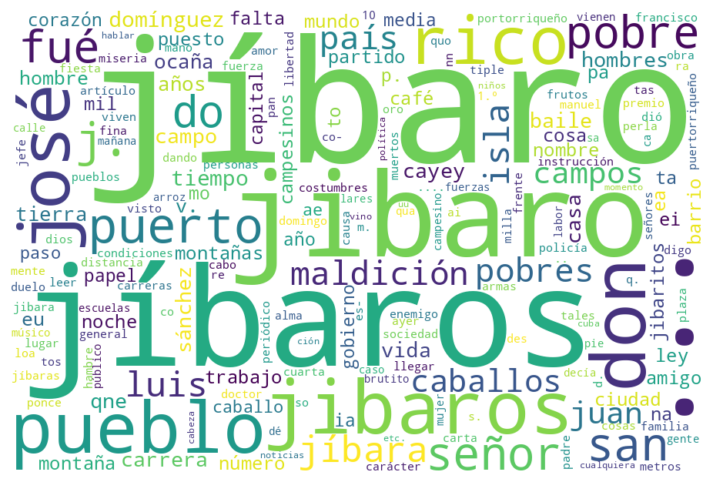

In [45]:
tfs = get_term_freqs(sentences)
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [44]:
sentences[0]

dice quina en ja integridad; siempre he creído que el verdadero jíbaro no se mezcla en las luchas políticas.

In [29]:
d = nlp(text)

In [38]:
token.sent

i ypfm saliva hermanos.

In [37]:
for token in d:
    print(f"Token: {token.text}")
    print(f"  POS tag: {token.pos_}")
    print(f"  Morphology: {token.morph}\n")
    print(f"  Sent Start?: {token.is_sent_start}\n")

Token: creído
  POS tag: VERB
  Morphology: Gender=Masc|Number=Sing|Tense=Past|VerbForm=Part

  Sent Start?: True

Token: ver
  POS tag: VERB
  Morphology: VerbForm=Inf

  Sent Start?: False

Token: algo
  POS tag: PRON
  Morphology: Number=Sing|PronType=Ind

  Sent Start?: False

Token: con
  POS tag: ADP
  Morphology: 

  Sent Start?: False

Token: que
  POS tag: PRON
  Morphology: PronType=Int,Rel

  Sent Start?: False

Token: jamás
  POS tag: ADV
  Morphology: 

  Sent Start?: False

Token: soñaron
  POS tag: VERB
  Morphology: Mood=Ind|Number=Plur|Person=3|Tense=Past|VerbForm=Fin

  Sent Start?: False

Token: los
  POS tag: DET
  Morphology: Definite=Def|Gender=Masc|Number=Plur|PronType=Art

  Sent Start?: False

Token: fieles
  POS tag: ADJ
  Morphology: Number=Plur

  Sent Start?: False

Token: habitantes
  POS tag: NOUN
  Morphology: Number=Plur

  Sent Start?: False

Token: de
  POS tag: ADP
  Morphology: 

  Sent Start?: False

Token: esta
  POS tag: DET
  Morphology: Gender=

In [11]:
data_df['doc_length = data_df['doc_cleaned'].apply(len)

<Axes: ylabel='Frequency'>

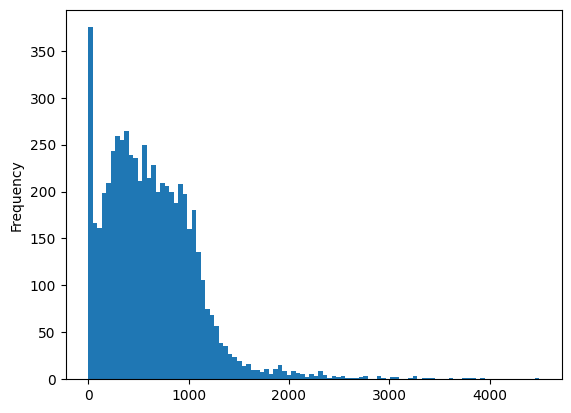

In [18]:
data_df.reset_index().groupby('link')['doc_length'].sum().plot.hist(bins=100)